# Разведывательный анализ данных

Этот ноутбук — учебный материал по разведывательному анализу данных (Exploratory Data Analysis, EDA). Цель — последовательно разобрать, *из каких шагов состоит EDA*, *зачем* делается каждый шаг и *как читать* его результат. Все примеры построены на простых, знакомых наборах данных, чтобы внимание оставалось на методе, а не на специфике предметной области. В конце ноутбука даётся явный план переноса этих приёмов на данные ветрогенератора.

## Зачем нужен EDA

Прежде чем строить любую модель машинного обучения или принимать решение на основе данных, мы должны ответить на несколько вопросов:

1. Что вообще лежит в этих данных — какие столбцы, какие типы, какие диапазоны?
2. Можно ли этим данным доверять — нет ли пропусков, ошибок ввода, дубликатов, физически невозможных значений?
3. Как переменные распределены и как они связаны друг с другом?
4. Есть ли выбросы и интересные подгруппы в данных?
5. Какие признаки потенциально полезны для целевой задачи, а какие избыточны или зашумлены?

EDA — это методичные ответы на эти вопросы. Без него любое моделирование строится вслепую: одна некорректно обработанная колонка может полностью испортить результат.

## Структура ноутбука

- Раздел 1. Подготовка окружения.
- Раздел 2. Загрузка данных и первый взгляд.
- Раздел 3. Проверка качества данных: типы, пропуски, дубликаты.
- Раздел 4. Описательная статистика.
- Раздел 5. Анализ распределений (одномерный анализ).
- Раздел 6. Анализ выбросов.
- Раздел 7. Связи между переменными (двумерный анализ).
- Раздел 8. Категориальные переменные и группировки.
- Раздел 9. Работа с временными рядами.
- Раздел 10. Несбалансированные классы.
- Раздел 11. Применение к данным ветрогенератора: план действий.

## 1. Подготовка окружения

Стандартный набор библиотек для EDA в Python — `pandas` для работы с таблицами, `numpy` для численных операций, `matplotlib` и `seaborn` для визуализации. В Google Colab они уже предустановлены, дополнительная установка не требуется.

Рекомендуется в начале каждого ноутбука явно задавать параметры отображения: ширину таблиц, формат чисел, стиль графиков. Это делает результаты предсказуемыми и удобными для чтения.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Параметры отображения таблиц
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Параметры графиков
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Окружение готово')

Окружение готово


## 2. Загрузка данных и первый взгляд

Будем работать с двумя классическими учебными наборами данных:

- **Titanic** — таблица пассажиров «Титаника» с признаками возраста, класса, пола, тарифа и т.д. и целевой переменной «выжил/не выжил». Хорошо подходит для иллюстрации работы с пропусками, категориальными переменными и несбалансированными классами.
- **Iris** — измерения цветов ириса трёх видов. Полностью числовой набор, идеально подходит для иллюстрации корреляций и распределений.

Оба набора доступны напрямую через `seaborn` — их не нужно скачивать вручную.

In [2]:
titanic = sns.load_dataset('titanic')
iris = sns.load_dataset('iris')

print(f'Titanic: {titanic.shape[0]} строк, {titanic.shape[1]} столбцов')
print(f'Iris   : {iris.shape[0]} строк, {iris.shape[1]} столбцов')

Titanic: 891 строк, 15 столбцов
Iris   : 150 строк, 5 столбцов


Первое, что делают с любым датасетом — смотрят на несколько первых строк методом `head()`. Это даёт интуитивное понимание: какие столбцы, как они выглядят, какие значения встречаются.

Не следует ограничиваться только `head()` (первые 5 строк). Полезно также вызвать `sample(5)` — случайная выборка покажет более разнообразные значения, тогда как первые строки часто отсортированы и содержат однотипные записи.

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.sample(5, random_state=42)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.246,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.000,0,0,10.500,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.000,0,0,7.925,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.000,0,1,33.000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.000,1,0,11.242,C,Third,child,False,NaN,Cherbourg,yes,False


**Как читать таблицу.** Уже из этих строк видно многое:

- `survived` — целевая переменная, бинарная (0/1);
- `pclass` — класс билета, число от 1 до 3 (по сути категориальная переменная, хоть и числовая);
- `sex`, `embarked`, `class`, `who`, `deck` — категориальные строковые столбцы, и `class` дублирует `pclass`;
- в `age` и `deck` уже на первых строках видны пропуски (`NaN`).

Метод `info()` даёт компактную сводку: типы столбцов, число непустых значений, объём памяти. Это первая проверка на пропуски и на корректность типов.

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 3. Проверка качества данных

На этом этапе отвечаем на вопрос: можно ли вообще работать с этими данными в текущем виде, или сперва требуется очистка.

Основные проверки:

1. Корректность типов столбцов (числа должны быть числами, даты — датами, не строками).
2. Пропуски: где они есть, сколько их, как с ними поступать.
3. Дубликаты строк — могут возникать из-за ошибок выгрузки.
4. Дубликаты столбцов по смыслу (`pclass` и `class` — пример).
5. Константные или почти константные столбцы — они не несут информации.

### 3.1. Пропуски

Для каждого столбца считаем число пропусков и их долю. Сортировка по убыванию помогает увидеть, где проблема наиболее острая.

In [6]:
missing = pd.DataFrame({
    'n_missing': titanic.isna().sum(),
    'pct_missing': (titanic.isna().mean() * 100).round(2)
}).sort_values('pct_missing', ascending=False)

missing[missing['n_missing'] > 0]

,n_missing,pct_missing
deck,688,77.220
age,177,19.870
embarked,2,0.220
embark_town,2,0.220


**Как читать.** Столбец `deck` пропущен на 77 % — заполнять его средним или модой не имеет смысла, такой столбец чаще всего лучше удалить полностью или превратить в бинарный признак «номер палубы известен / неизвестен». Столбец `age` пропущен на 20 % — это умеренный уровень, его можно осмысленно заполнить (например, медианой по полу и классу). Пропуски в `embarked` — единичные, их можно безопасно заполнить модой.

Общее правило: **способ обработки пропусков зависит от их доли и природы**.

- Менее 5 % пропусков — обычно можно безопасно заполнить медианой/модой или удалить строки.
- От 5 до 30 % — нужен осмысленный подход: заполнение по группам, индикатор пропуска как отдельный признак, специальные алгоритмы импутации.
- Более 30–40 % — серьёзный вопрос, насколько такой столбец вообще пригоден.

Полезно также визуализировать карту пропусков — это позволяет увидеть, не идут ли пропуски «полосами» (т.е. не связаны ли они с какими-то периодами или подгруппами).

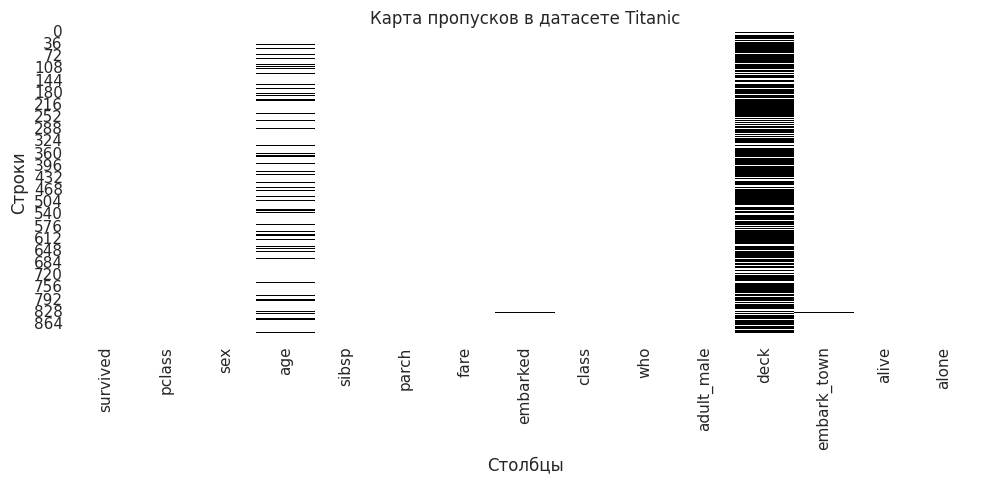

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(titanic.isna(), cbar=False, cmap='Greys', ax=ax)
ax.set_title('Карта пропусков в датасете Titanic')
ax.set_xlabel('Столбцы')
ax.set_ylabel('Строки')
plt.tight_layout()
plt.show()

### 3.2. Дубликаты

Полные дубликаты строк часто появляются из-за ошибок при объединении таблиц или повторной выгрузки данных. Их обычно удаляют.

In [8]:
print(f'Полных дубликатов строк в Titanic: {titanic.duplicated().sum()}')
print(f'Полных дубликатов строк в Iris   : {iris.duplicated().sum()}')

Полных дубликатов строк в Titanic: 107
Полных дубликатов строк в Iris   : 1


Оба числа на первый взгляд : 107 «дубликатов» в Titanic и 1 в Iris. Но прежде чем что-либо удалять, нужно понять, что именно `duplicated()` нашёл. Метод проверяет совпадение по **всем столбцам таблицы** — а не наличие повторно записанного пассажира или особи. Если в данных нет уникального идентификатора (паспорта, серийного номера, ID), то две физически разные сущности с одинаковыми наблюдаемыми признаками будут выглядеть как дубликат, не являясь им. Это очень частая ситуация.




In [9]:
# Посмотрим на конкретные строки, помеченные как дубликат
dups = titanic[titanic.duplicated(keep=False)].sort_values(list(titanic.columns))
dups.head(8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
64,0,1,male,NaN,0,0,27.721,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.721,C,First,man,True,NaN,Cherbourg,no,True
144,0,2,male,18.000,0,0,11.500,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.000,0,0,11.500,S,Second,man,True,NaN,Southampton,no,True
658,0,2,male,23.000,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True
733,0,2,male,23.000,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True
734,0,2,male,23.000,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True
134,0,2,male,25.000,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True


**Что мы видим строго по данным.** Среди этих строк есть группы, в которых все 15 столбцов идентичны: совпадают `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`. Например, строки 64 и 295 — одинокие мужчины первого класса из Шербура с тарифом 27.721, погибшие; строки 658, 733 и 734 — одинокие мужчины 23 лет из второго класса с тарифом 13.000 из Саутгемптона, погибшие. По доступным столбцам различить эти строки невозможно — у них нет ни одного отличающегося признака.

**Какие выводы из этого следуют — и какие нет.**

Из факта, что 107 строк полностью совпадают по 15 столбцам, **строго не следует**, что:

- это разные пассажиры — мы не можем это утверждать, не имея идентифицирующего признака (имени, номера билета, ID);
- это технические дубликаты — мы не можем это утверждать без обращения к источнику данных.

То, что **следует** строго:

- По имеющимся столбцам эти наблюдения неразличимы. Любая модель машинного обучения, обученная на этих данных, будет видеть их как одинаковые объекты и давать им одинаковые предсказания.
- Прежде чем удалять или сохранять такие строки, нужно вернуться к источнику данных и проверить наличие уникального идентификатора. В этой учебной версии датасета (загруженной через `seaborn`) такого идентификатора нет — столбцы `PassengerId`, `Name`, `Ticket` не входят в выборку.

**Практический принцип работы с дубликатами:**

1. **Сначала проверьте, есть ли в данных уникальный идентификатор** — серийный номер, ID транзакции, номер пассажира. Если есть — ищите дубликаты по нему. Совпадение по ID — это почти всегда ошибка, такие строки удаляются.
2. **Если уникального идентификатора нет** — `duplicated()` по всем столбцам отвечает только на технический вопрос «есть ли строки с идентичными значениями». На вопрос «являются ли это ошибками выгрузки» он не отвечает — нужно обращение к источнику.
3. **Если решение неоднозначно — фиксируйте факт совпадений в журнале анализа и не удаляйте строки автоматически.** Удалить данные легко, восстановить — нет.

В этом учебном ноутбуке мы не удаляем эти строки: без идентификатора у нас нет оснований ни считать их ошибками, ни считать их разными наблюдениями.

### 3.3. Дубликаты по смыслу и константные столбцы

Иногда два столбца содержат одну и ту же информацию в разном представлении. В Titanic есть как `pclass` (число), так и `class` (строка): «First», «Second», «Third». Полезно проверять такие пары.

In [10]:
# Сравниваем pclass и class
print(pd.crosstab(titanic['pclass'], titanic['class']))

class   First  Second  Third
pclass                      
1         216       0      0
2           0     184      0
3           0       0    491


Видно, что соответствие однозначное: класс 1 — это всегда «First», и так далее. Один из этих столбцов избыточен. То же стоит проверять для пар вроде `embark_town` и `embarked`.

Поиск константных или почти константных столбцов делается через число уникальных значений: если у столбца всего одно значение на тысячи строк — он бесполезен для анализа.

In [11]:
n_unique = titanic.nunique()
print('Число уникальных значений по столбцам:')
print(n_unique.sort_values())

Число уникальных значений по столбцам:
survived         2
sex              2
alive            2
adult_male       2
alone            2
class            3
pclass           3
embarked         3
embark_town      3
who              3
sibsp            7
parch            7
deck             7
age             88
fare           248
dtype: int64


## 4. Описательная статистика

После проверки структуры данные изучают статистически. Метод `describe()` сразу даёт по каждому числовому столбцу: среднее, стандартное отклонение, минимум, максимум и квартили (25-й, 50-й, 75-й перцентили).

**Как читать `describe()`.**

- Сравните `mean` и `50%` (медиану): если они сильно различаются — распределение асимметричное.
- Сравните `min` / `max` и квартили: если максимум на порядок больше 75-го перцентиля — есть выбросы.
- Подозрительные минимумы (например, отрицательный возраст или нулевой рост) — повод проверить корректность данных.

In [12]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000,891.000,714.000,891.000,891.000,891.000
mean,0.384,2.309,29.699,0.523,0.382,32.204
std,0.487,0.836,14.526,1.103,0.806,49.693
min,0.000,1.000,0.420,0.000,0.000,0.000
25%,0.000,2.000,20.125,0.000,0.000,7.910
50%,0.000,3.000,28.000,0.000,0.000,14.454
75%,1.000,3.000,38.000,1.000,0.000,31.000
max,1.000,3.000,80.000,8.000,6.000,512.329


**Наблюдения по Titanic.**

- `fare`: среднее 32, медиана 14, максимум 512 — резкая асимметрия, в данных есть пассажиры с экстремально дорогими билетами.
- `age`: среднее 29, медиана 28, минимум 0.42, максимум 80 — выглядит правдоподобно, минимум — младенец нескольких месяцев от роду.
- `sibsp` и `parch` имеют максимум 8 и 6 — крупные семьи на борту.

Для категориальных столбцов используется отдельный вызов с параметром `include='object'`:

In [13]:
titanic.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


Здесь смысл колонок другой: `count` — число непустых значений, `unique` — число уникальных категорий, `top` — самая частая категория, `freq` — сколько раз она встретилась.

## 5. Анализ распределений (одномерный анализ)

На этом этапе изучается распределение каждой переменной по отдельности — её форма, центр, разброс, наличие выбросов и аномалий. Основные инструменты: **гистограмма** и **box plot** (ящик с усами).

### 5.1. Гистограмма

Гистограмма показывает, как часто встречаются те или иные диапазоны значений. По её форме можно понять:

- симметрично ли распределение или скошено;
- одномодальное оно или многомодальное (несколько пиков);
- какие значения наиболее типичны.

На примере возраста пассажиров Titanic:

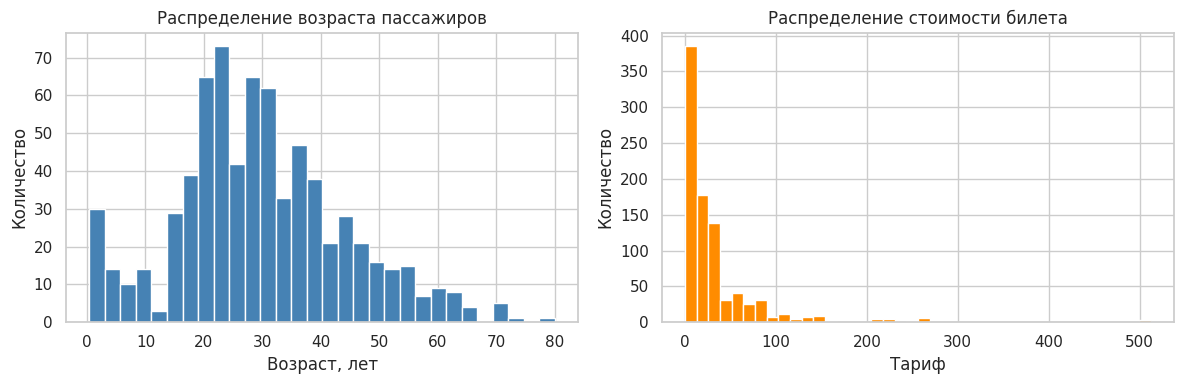

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение возраста пассажиров')
axes[0].set_xlabel('Возраст, лет')
axes[0].set_ylabel('Количество')

axes[1].hist(titanic['fare'].dropna(), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Распределение стоимости билета')
axes[1].set_xlabel('Тариф')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

**Как читать.**

- Возраст — относительно симметричное распределение с пиком в районе 20–30 лет и небольшим вторичным пиком на детях (0–10 лет). Это разумная картина для пассажирского лайнера.
- Тариф — сильно скошенное распределение: большинство билетов дешёвые, но есть длинный «хвост» дорогих. Такие распределения часто полезно логарифмировать при моделировании, чтобы привести к более симметричному виду.

### 5.2. Выбор числа интервалов (`bins`)

Количество интервалов в гистограмме существенно влияет на восприятие. Слишком мало — теряются детали; слишком много — видна шумовая дробность. Полезно строить с разным количеством, чтобы убедиться, что вывод устойчив.

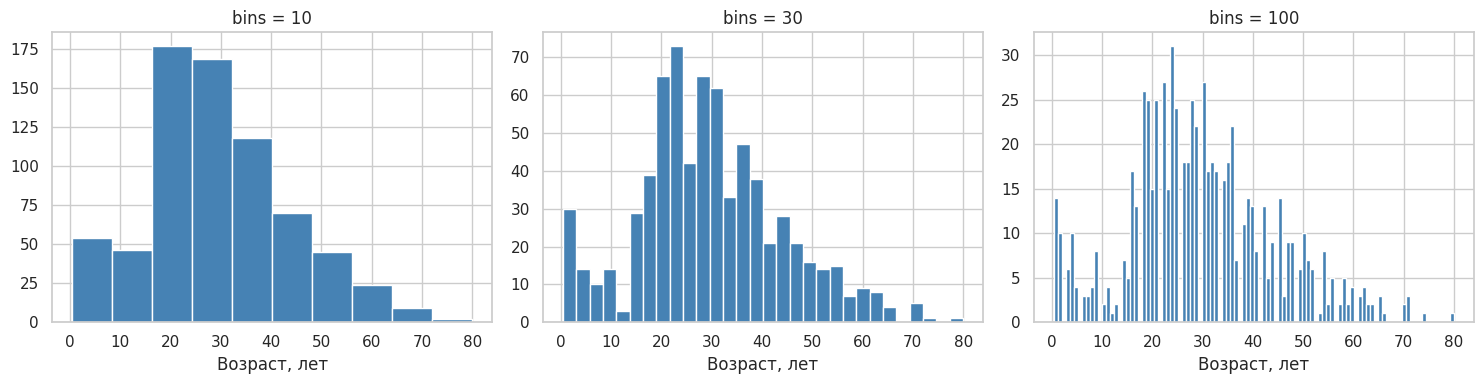

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [10, 30, 100]):
    ax.hist(titanic['age'].dropna(), bins=b, color='steelblue', edgecolor='white')
    ax.set_title(f'bins = {b}')
    ax.set_xlabel('Возраст, лет')
plt.tight_layout()
plt.show()

### 5.3. Box plot — ящик с усами

Box plot — компактный способ показать распределение и выбросы одновременно. Он визуализирует:

- медиану (линия внутри «ящика»);
- квартили Q1 и Q3 (границы ящика);
- «усы», обычно идущие на расстояние 1.5 * IQR (межквартильного размаха);
- точки за усами — формальные выбросы по правилу Тьюки.

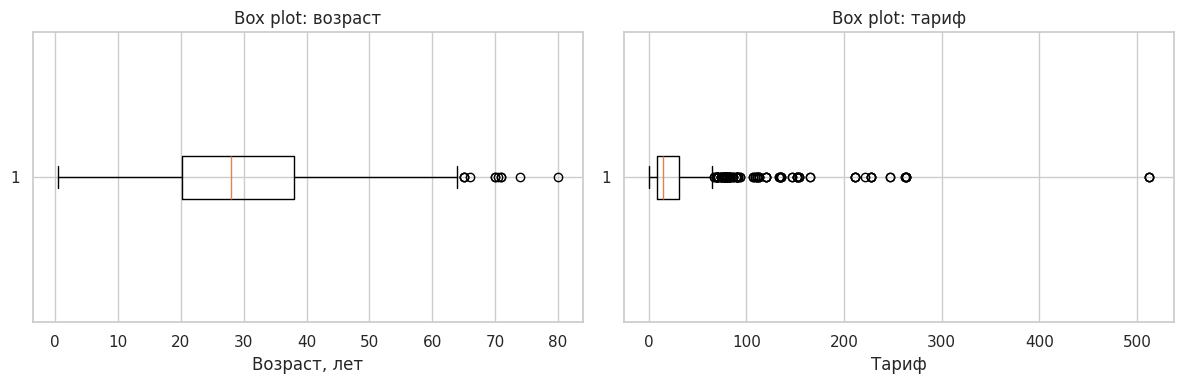

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(titanic['age'].dropna(), vert=False)
axes[0].set_title('Box plot: возраст')
axes[0].set_xlabel('Возраст, лет')

axes[1].boxplot(titanic['fare'].dropna(), vert=False)
axes[1].set_title('Box plot: тариф')
axes[1].set_xlabel('Тариф')
plt.tight_layout()
plt.show()

В тарифе видно множество точек за правым усом — формальные выбросы по правилу IQR. Однако (см. следующий раздел) это не обязательно «ошибки» — это могут быть просто дорогие билеты.

## 6. Анализ выбросов

Выбросы — наблюдения, существенно отличающиеся от остальных. Существуют два принципиально разных типа:

1. **Ошибки в данных** — некорректные значения (отрицательный возраст, температура 9999 °C, опечатки). Их нужно исправлять или удалять.
2. **Редкие, но реальные наблюдения** — это часть данных, и часто как раз самая интересная часть. Удалять их означает ухудшать модель.

Самый частый формальный критерий — правило межквартильного размаха (IQR):

- IQR = Q3 − Q1
- Нижняя граница: Q1 − k * IQR (обычно k = 1.5)
- Верхняя граница: Q3 + k * IQR

Значения за этими границами помечаются как выбросы. Это формальный, а не физический критерий.

In [17]:
def iqr_outliers(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    is_out = (s < low) | (s > high)
    return {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'low_bound': low, 'high_bound': high,
        'n_outliers': int(is_out.sum()),
        'share_%': round(is_out.mean() * 100, 2)
    }

print('Возраст:')
print(iqr_outliers(titanic['age']))
print('\nТариф:')
print(iqr_outliers(titanic['fare']))

Возраст:
{'Q1': 20.125, 'Q3': 38.0, 'IQR': 17.875, 'low_bound': -6.6875, 'high_bound': 64.8125, 'n_outliers': 11, 'share_%': np.float64(1.54)}

Тариф:
{'Q1': 7.9104, 'Q3': 31.0, 'IQR': 23.0896, 'low_bound': -26.724, 'high_bound': 65.6344, 'n_outliers': 116, 'share_%': np.float64(13.02)}


**Интерпретация.** Для тарифа правило IQR находит 13 % «выбросов» — это много. Но мы знаем из контекста, что на Titanic действительно были богатые пассажиры первого класса с дорогими билетами. Это не ошибки, а реальная часть данных. Если такие точки удалить, модель «забудет» о существовании первого класса.

**Главный практический вывод:** прежде чем удалять выбросы, нужно понять, что они означают. Полезный приём — посмотреть на конкретные строки-выбросы.

In [18]:
# Топ-5 самых дорогих билетов
titanic.nlargest(5, 'fare')[['pclass', 'sex', 'age', 'fare', 'embarked', 'survived']]

,pclass,sex,age,fare,embarked,survived
258,1,female,35.000,512.329,C,1
679,1,male,36.000,512.329,C,1
737,1,male,35.000,512.329,C,1
27,1,male,19.000,263.000,S,0
88,1,female,23.000,263.000,S,1


Видно, что самые дорогие билеты — у пассажиров первого класса. Эти строки не похожи на технические ошибки и должны остаться в данных.

## 7. Связи между переменными (двумерный анализ)

Одномерный анализ говорит о каждой переменной по отдельности. Следующий шаг — изучить **связи между парами переменных**. Это центральная часть EDA: именно здесь обнаруживаются закономерности, полезные для моделирования.

Инструменты зависят от типов переменных:

| Тип переменной X | Тип переменной Y | Инструмент |
|---|---|---|
| числовая | числовая | scatter plot, корреляция |
| категориальная | числовая | box plot по группам, средние |
| категориальная | категориальная | crosstab, тепловая карта |

### 7.1. Числовая vs числовая: scatter plot и корреляция

Удобный пример — датасет Iris. Все его признаки числовые, и каждая пара показывает разные закономерности.

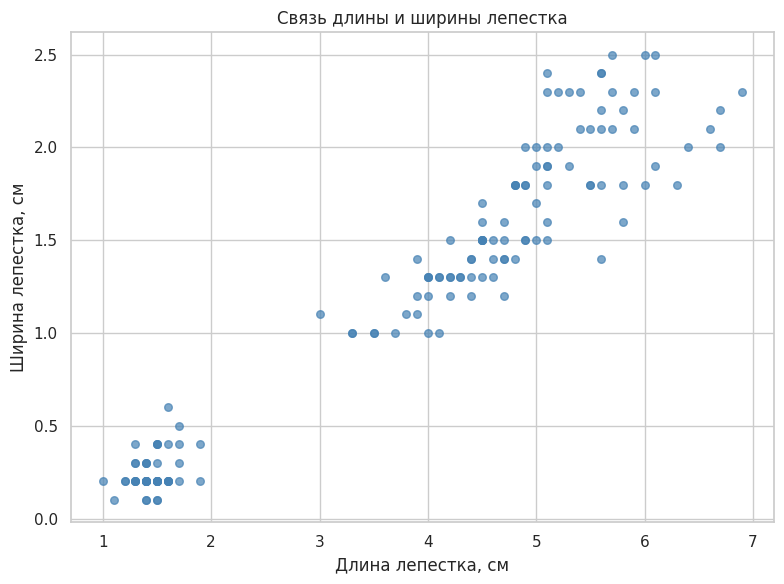

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(iris['petal_length'], iris['petal_width'], s=30, alpha=0.7, color='steelblue')
ax.set_title('Связь длины и ширины лепестка')
ax.set_xlabel('Длина лепестка, см')
ax.set_ylabel('Ширина лепестка, см')
plt.tight_layout()
plt.show()

**Как читать.** Видна сильная положительная связь: чем длиннее лепесток, тем он шире. Также видна группировка точек в два «облака» — это намекает, что в данных есть подгруппы (на самом деле — три вида ирисов, в чём мы сейчас убедимся).

**Коэффициент корреляции** формализует эту связь одним числом от −1 до +1:

- +1: идеальная положительная линейная связь;
- 0: линейной связи нет;
- −1: идеальная отрицательная.

Корреляционная матрица показывает все попарные коэффициенты сразу.

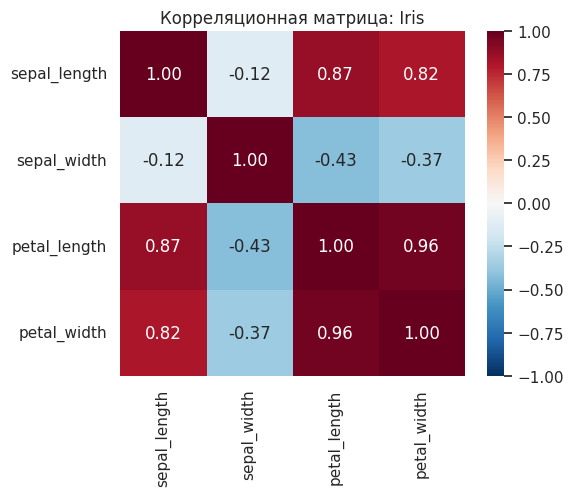

In [20]:
corr = iris.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Корреляционная матрица: Iris')
plt.tight_layout()
plt.show()

**Важные оговорки про корреляцию.**

1. Коэффициент Пирсона улавливает только **линейные** связи. Две переменные могут быть тесно связаны нелинейно, и Пирсон даст близкое к нулю значение. Поэтому корреляцию полезно дополнять scatter-графиками.
2. Корреляция не означает причинность. Если две переменные коррелируют, это не значит, что одна вызывает другую — обе могут зависеть от третьей.
3. Высокая корреляция между двумя признаками — повод задуматься о мультиколлинеарности при построении модели.

### 7.2. Pair plot — все пары сразу

Когда числовых столбцов немного (до 6–8), удобно построить матрицу всех попарных scatter-графиков одной командой:

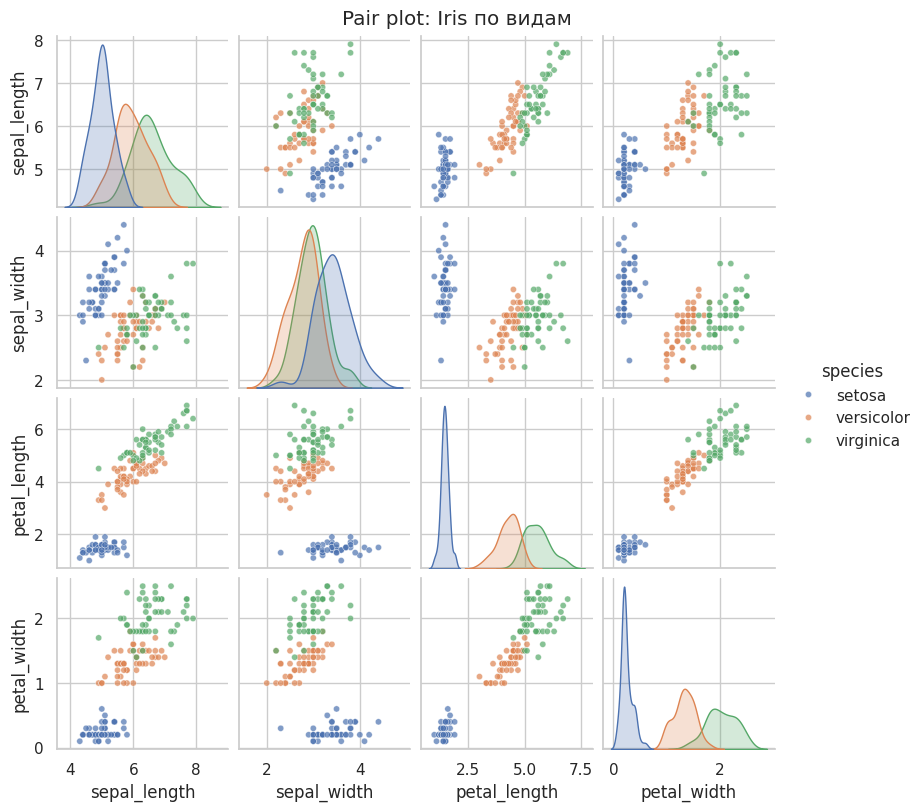

In [21]:
sns.pairplot(iris, hue='species', height=2.0, plot_kws={'s': 20, 'alpha': 0.7})
plt.suptitle('Pair plot: Iris по видам', y=1.01)
plt.show()

**Как читать pair plot.** На диагонали — распределения каждой переменной (гистограммы или плотности), вне диагонали — scatter-графики каждой пары. Параметр `hue='species'` раскрашивает точки по виду цветка. Видно, что по лепестковым признакам три вида разделяются очень чётко — это значит, что задача классификации в этом датасете легко решается. По чашелистикам разделение слабее.

### 7.3. Категориальная vs числовая

Сравниваем распределения числовой переменной по группам категориальной. Самый информативный инструмент — box plot по группам или его улучшенная версия `violinplot`.

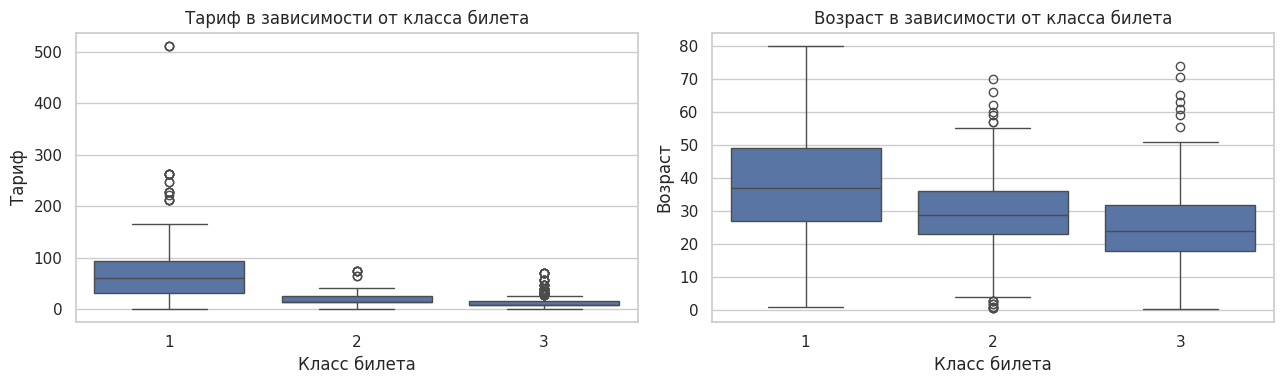

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[0])
axes[0].set_title('Тариф в зависимости от класса билета')
axes[0].set_xlabel('Класс билета')
axes[0].set_ylabel('Тариф')

sns.boxplot(data=titanic, x='pclass', y='age', ax=axes[1])
axes[1].set_title('Возраст в зависимости от класса билета')
axes[1].set_xlabel('Класс билета')
axes[1].set_ylabel('Возраст')

plt.tight_layout()
plt.show()

**Наблюдения.**

- Тариф резко выше в первом классе — это ожидаемо.
- Пассажиры первого класса в среднем старше, в третьем — моложе.

Тот же анализ можно делать через средние по группам — это часто бывает удобнее для отчёта:

In [23]:
titanic.groupby('pclass')[['age', 'fare', 'survived']].mean().round(2)

,age,fare,survived
pclass,,,
1,38.230,84.150,0.630
2,29.880,20.660,0.470
3,25.140,13.680,0.240


В таблице сразу виден важный паттерн: средняя доля выживших падает от первого класса (63 %) к третьему (24 %). Это уже не просто описание данных, это инсайт, ценный для моделирования.

### 7.4. Категориальная vs категориальная

Для пары категориальных переменных применяется таблица сопряжённости (`crosstab`). Удобно нормировать её по строкам, чтобы видеть доли.

In [24]:
# Абсолютные числа
ct_counts = pd.crosstab(titanic['sex'], titanic['survived'])
print('Абсолютные числа:')
print(ct_counts)

# Доли по строкам
ct_norm = pd.crosstab(titanic['sex'], titanic['survived'], normalize='index')
print('\nДоли по полу (строкам):')
print(ct_norm.round(3))

Абсолютные числа:
survived    0    1
sex               
female     81  233
male      468  109

Доли по полу (строкам):
survived     0     1
sex                 
female   0.258 0.742
male     0.811 0.189


**Наблюдение.** Среди женщин выжило 74 %, среди мужчин — лишь 19 %. Пол — самый сильный одиночный предиктор выживания на «Титанике».

## 8. Категориальные переменные и группировки

Категориальные переменные требуют отдельного внимания. Полезные приёмы:

1. Подсчёт значений `value_counts()` — частоты категорий.
2. Группировки `groupby()` со сводными статистиками.
3. Сводные таблицы `pivot_table()` для двух категориальных переменных.

In [25]:
# Частоты
print('Распределение по портам посадки:')
print(titanic['embarked'].value_counts())
print()
print('То же в виде долей:')
print(titanic['embarked'].value_counts(normalize=True).round(3))

Распределение по портам посадки:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

То же в виде долей:
embarked
S   0.724
C   0.189
Q   0.087
Name: proportion, dtype: float64


Доля выживших по полу и классу:
pclass     1     2     3
sex                     
female 0.968 0.921 0.500
male   0.369 0.157 0.135


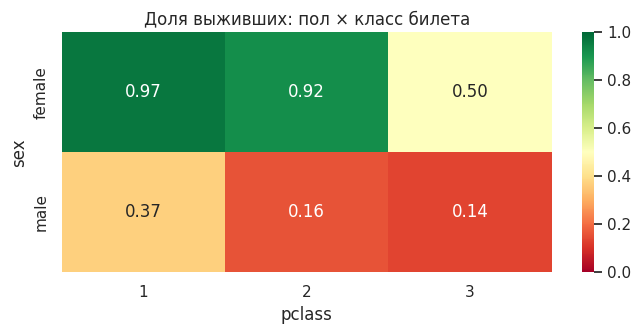

In [26]:
# Сводная таблица: доля выживших по полу и классу
pivot = titanic.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')
print('Доля выживших по полу и классу:')
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Доля выживших: пол × класс билета')
plt.tight_layout()
plt.show()

**Наблюдение.** Сводная таблица одной картинкой даёт ясную закономерность: женщины первого класса выживали почти всегда (97 %), мужчины третьего класса — почти никогда (14 %). Это типичный пример того, как EDA сразу указывает на сильные предикторы.

## 9. Работа с временными рядами

Если данные содержат столбец с датой/временем, появляется дополнительный набор приёмов EDA. Это особенно важно для SCADA-данных ветрогенератора. Создадим простой синтетический пример: посуточные продажи с сезонностью.

In [27]:
# Синтетический временной ряд
rng = np.random.default_rng(42)
dates = pd.date_range('2023-01-01', '2024-12-31', freq='D')
trend = np.linspace(100, 150, len(dates))
season = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 365)
weekly = 10 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)
noise = rng.normal(0, 5, len(dates))
sales = trend + season + weekly + noise

ts = pd.DataFrame({'date': dates, 'sales': sales})
ts['date'] = pd.to_datetime(ts['date'])
ts.head()

,date,sales
0,2023-01-01,101.524
1,2023-01-02,103.031
2,2023-01-03,114.327
3,2023-01-04,110.280
4,2023-01-05,87.556


### 9.1. Проверка временного покрытия

Первое, что проверяют во временном ряду — что временные метки идут регулярно, без больших разрывов и без дубликатов.

In [28]:
print(f'Период: {ts["date"].min().date()} — {ts["date"].max().date()}')
print(f'Длина: {len(ts)} записей')

intervals = ts['date'].diff().dropna()
print(f'\nИнтервалы между записями:')
print(intervals.describe())
print(f'\nЧисло дубликатов даты: {ts["date"].duplicated().sum()}')

Период: 2023-01-01 — 2024-12-31
Длина: 731 записей

Интервалы между записями:
count                730
mean     1 days 00:00:00
std      0 days 00:00:00
min      1 days 00:00:00
25%      1 days 00:00:00
50%      1 days 00:00:00
75%      1 days 00:00:00
max      1 days 00:00:00
Name: date, dtype: object

Число дубликатов даты: 0


### 9.2. Базовый график ряда

Простая линия по времени — первая визуализация любого временного ряда. По ней видны тренд, сезонность, выбросы.

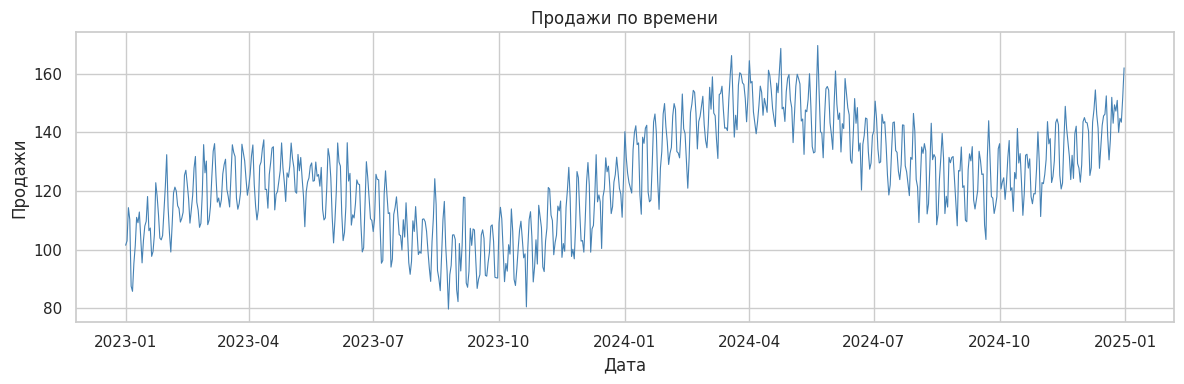

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts['date'], ts['sales'], linewidth=0.8, color='steelblue')
ax.set_title('Продажи по времени')
ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')
plt.tight_layout()
plt.show()

### 9.3. Сглаживание для выявления тренда

Шум часто маскирует структуру. Скользящее среднее (`rolling`) помогает увидеть тренд:

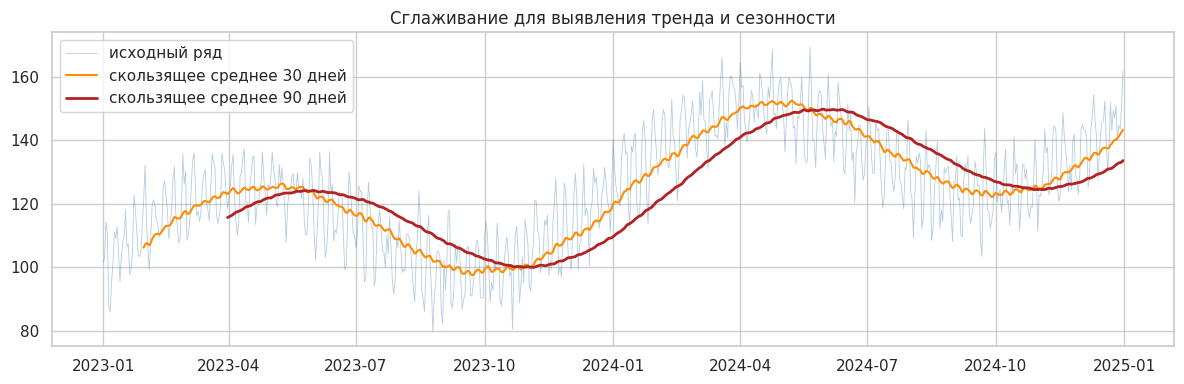

In [30]:
ts['sma_30'] = ts['sales'].rolling(window=30).mean()
ts['sma_90'] = ts['sales'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts['date'], ts['sales'], linewidth=0.6, alpha=0.4, color='steelblue', label='исходный ряд')
ax.plot(ts['date'], ts['sma_30'], linewidth=1.5, color='darkorange', label='скользящее среднее 30 дней')
ax.plot(ts['date'], ts['sma_90'], linewidth=2, color='firebrick', label='скользящее среднее 90 дней')
ax.set_title('Сглаживание для выявления тренда и сезонности')
ax.legend()
plt.tight_layout()
plt.show()

**Как читать.** 30-дневное среднее снимает недельные колебания и обнажает годовую сезонность. 90-дневное — снимает и её, оставляя только долгосрочный тренд (мы заложили его явно при генерации). Это базовая идея декомпозиции временного ряда: тренд + сезонность + шум.

### 9.4. Анализ по дню недели / часу

Полезные признаки времени легко извлекаются из datetime: день недели, час, месяц. Группировки по ним выявляют циклические эффекты.

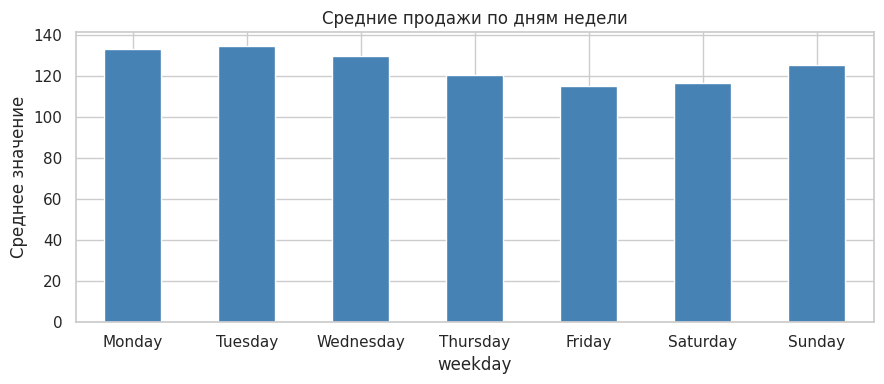

In [31]:
ts['weekday'] = ts['date'].dt.day_name()
ts['month']   = ts['date'].dt.month_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_weekday = ts.groupby('weekday')['sales'].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 4))
by_weekday.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Средние продажи по дням недели')
ax.set_ylabel('Среднее значение')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Несбалансированные классы

Очень частая ситуация в реальных данных: целевая переменная сильно перекошена. Примеры — обнаружение мошенничества (доля мошенников — доли процента), отказы оборудования, медицинские диагнозы редких заболеваний.

Это серьёзная проблема для моделирования: модель, которая всегда предсказывает мажоритарный класс, формально получит высокую точность, но не будет иметь никакой практической ценности.

На примере Titanic:

In [32]:
balance = titanic['survived'].value_counts(normalize=True).round(3)
print('Распределение целевой переменной (выживание):')
print(balance)
print(f'\nДоля мажоритарного класса: {balance.max() * 100:.1f} %')

Распределение целевой переменной (выживание):
survived
0   0.616
1   0.384
Name: proportion, dtype: float64

Доля мажоритарного класса: 61.6 %


На «Титанике» 62 % погибших и 38 % выживших — лёгкий дисбаланс, моделирование возможно стандартными способами. Но представим себе ситуацию, когда отказ происходит в 1 случае из 100 — это уже сильный дисбаланс.

Создадим искусственный сильно несбалансированный датасет и визуализируем его:

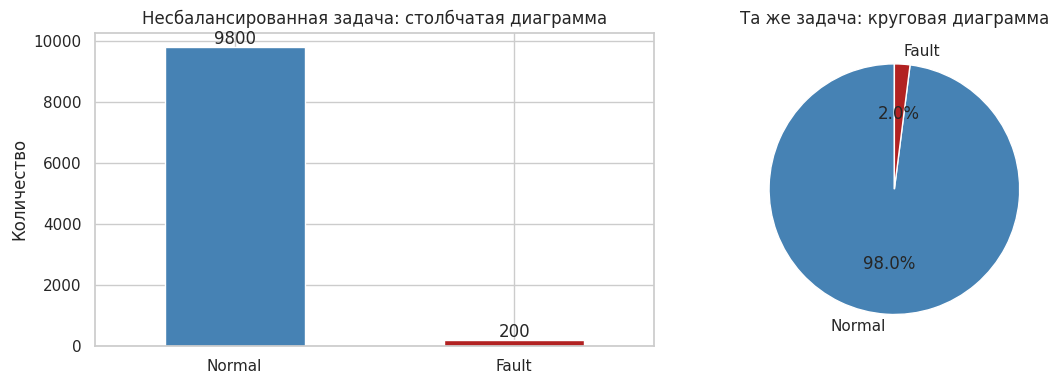

In [33]:
rng = np.random.default_rng(0)
n_normal = 9800
n_fault = 200
labels = ['Normal'] * n_normal + ['Fault'] * n_fault
imbalanced = pd.Series(labels).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

imbalanced.plot(kind='bar', color=['steelblue', 'firebrick'], ax=axes[0])
axes[0].set_title('Несбалансированная задача: столбчатая диаграмма')
axes[0].set_ylabel('Количество')
for i, v in enumerate(imbalanced):
    axes[0].text(i, v + 100, str(v), ha='center')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(imbalanced, labels=imbalanced.index,
            colors=['steelblue', 'firebrick'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Та же задача: круговая диаграмма')

plt.tight_layout()
plt.show()

**Что делать с дисбалансом.**

1. **Использовать правильные метрики.** Не accuracy, а precision/recall, F1, ROC-AUC, PR-AUC. Recall по миноритарному классу часто важнее всего: пропустить отказ — дорого.
2. **Балансировка обучающей выборки.** Под-выборка мажоритарного класса (undersampling), синтетические примеры миноритарного (SMOTE и аналоги), взвешивание классов через `class_weight`.
3. **Сменить постановку задачи.** Иногда вместо классификации правильнее формулировать задачу как обнаружение аномалий (one-class), обучаясь только на нормальном режиме и помечая всё необычное как подозрительное.
4. **Стратифицированное разбиение.** При разбиении на train/test обязательно сохранять долю классов через `stratify`.

## 11. Применение к данным ветрогенератора: план действий

Все приёмы, разобранные выше, прямо переносятся на анализ данных ветрогенератора. Здесь приведён конкретный план, в каком порядке их применять.

**Шаг 1. Загрузка и первичный осмотр.** Загрузить три CSV (`scada_data`, `status_data`, `fault_data`). Привести столбцы времени к типу datetime. Применить `head()`, `info()`, `describe()` к каждому. Так выявляется состав каналов SCADA, типы статусов, типы отказов.

**Шаг 2. Проверка качества.** Посчитать пропуски по каждой таблице (раздел 3 этого ноутбука). Обратить внимание на строковые поля журнала статусов, которые могут оказаться булевыми — `Service`, `FaultMsg`. Привести типы. Проверить полные дубликаты, проверить парные столбцы на смысловую избыточность.

**Шаг 3. Временное покрытие.** Это специфично для ветрогенератора: три источника записаны в разных временных диапазонах. Построить график-полосы (раздел 9), посчитать пересечение трёх периодов, оценить, какая доля SCADA-данных лежит вне общего периода — для них отсутствие записи отказа нельзя интерпретировать как «отказа нет».

**Шаг 4. Анализ распределений SCADA.** Для ключевых каналов — скорость ветра, мощность, температуры — построить гистограммы и box plot'ы (раздел 5). Скорость ветра ожидаемо близка к Вейбулловскому распределению, мощность сильно скошена с массой нулей. По таблицам `describe` и box plot искать физически невозможные значения (отрицательные температуры, неправдоподобные пики).

**Шаг 5. Анализ выбросов в SCADA.** Применить правило IQR (раздел 6), но трактовать результаты осторожно: для скорости ветра «выбросы» по IQR — это просто редкие, но реальные значения, не ошибки. Удалять следует только физически невозможные.

**Шаг 6. Корреляции каналов SCADA.** Построить корреляционную матрицу (раздел 7). Особое внимание — кластеру температурных каналов: каналы одной подсистемы будут сильно скоррелированы между собой, это признак избыточности. Решение — либо использование представителей кластеров, либо снижение размерности.

**Шаг 7. Анализ журнала отказов и статусов.** Применить таблицы частот и crosstab'ы (раздел 8): распределение по типам отказов, помесячная динамика, длительности нахождения в статусах. Здесь же — переход к пониманию структуры классов задачи.

**Шаг 8. Кривая мощности.** Это специфический инструмент ветроэнергетики, но методически — обычный scatter plot двух числовых переменных (раздел 7) с группировкой по бинам. Помогает увидеть точки, лежащие ниже эталонной кривой — кандидатов на разметку как аномалии.

**Шаг 9. Объединение источников и анализ дисбаланса.** Сопоставить каждое окно SCADA с ближайшей записью отказа через `pd.merge_asof` с допуском. Записи без отказа разметить как `NF` (нормальный режим). Построить круговую диаграмму классов (раздел 10) — на ветрогенераторе доля `NF` превышает 98 %, это сильный дисбаланс, и из него следуют все рекомендации раздела 10.

**Шаг 10. Сводная таблица признаков по классам.** Применить `groupby('Fault').mean()` к объединённой таблице и сравнить средние значения каналов SCADA в разных режимах. Каналы, средние которых заметно отличаются в режиме отказа от нормального — первые кандидаты в признаки модели.

Эти десять шагов и составляют полный разведывательный анализ данных.
